In [1]:
# Import the libraries used for analysis and plotting
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Apply a clean visual style
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
pd.set_option("display.max_columns", None)

In [2]:
# Load the supplied ecommerce CSV file
csv_path = Path(r"C:\Users\Admin\Downloads\ecommerce_dataset.csv")
df = pd.read_csv(csv_path)

# Clean column names and convert key fields to useful types
df.columns = df.columns.str.strip()
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")
numeric_columns = ["Sales", "Profit", "Quantity"]
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors="coerce")
df = df.dropna(subset=["Order_Date"] + numeric_columns).copy()

# Preview the cleaned data
print(f"Rows: {len(df):,}")
print(f"Date range: {df['Order_Date'].min().date()} to {df['Order_Date'].max().date()}")
df.head()

Rows: 200
Date range: 2025-01-01 to 2025-07-19


,Order_ID,Order_Date,City,Category,Product,Quantity,Unit_Price,Discount,Sales,Cost,Profit,Payment_Mode,Rating,Delivery_Days
0,1001,2025-01-01,Chennai,Furniture,Sofa,4,17396,0,69584.00,46310.58,23273.42,Card,5,5
1,1002,2025-01-02,Pune,Grocery,Snacks,3,46675,0,140025.00,92774.12,47250.88,Cash,5,5
2,1003,2025-01-03,Hyderabad,Electronics,Headphones,1,8305,25,6228.75,3627.01,2601.74,Net Banking,5,4
3,1004,2025-01-04,Hyderabad,Furniture,Chair,4,5737,0,22948.00,16485.86,6462.14,Net Banking,4,6
4,1005,2025-01-05,Bengaluru,Furniture,Bed,6,20556,20,98668.80,78019.85,20648.95,UPI,5,3


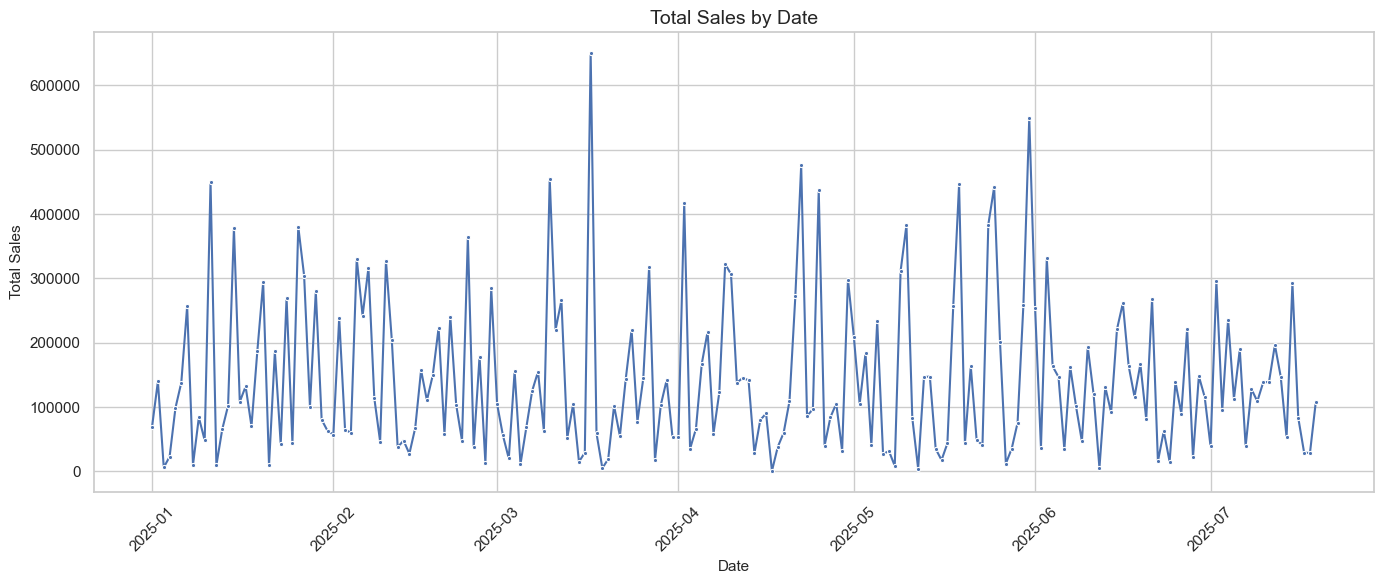

In [3]:
# Aggregate total sales by date
daily_sales = df.groupby("Order_Date", as_index=False)["Sales"].sum()

# Plot total sales by date
plt.figure(figsize=(14, 6))
sns.lineplot(data=daily_sales, x="Order_Date", y="Sales", marker="o", markersize=3)
plt.title("Total Sales by Date")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

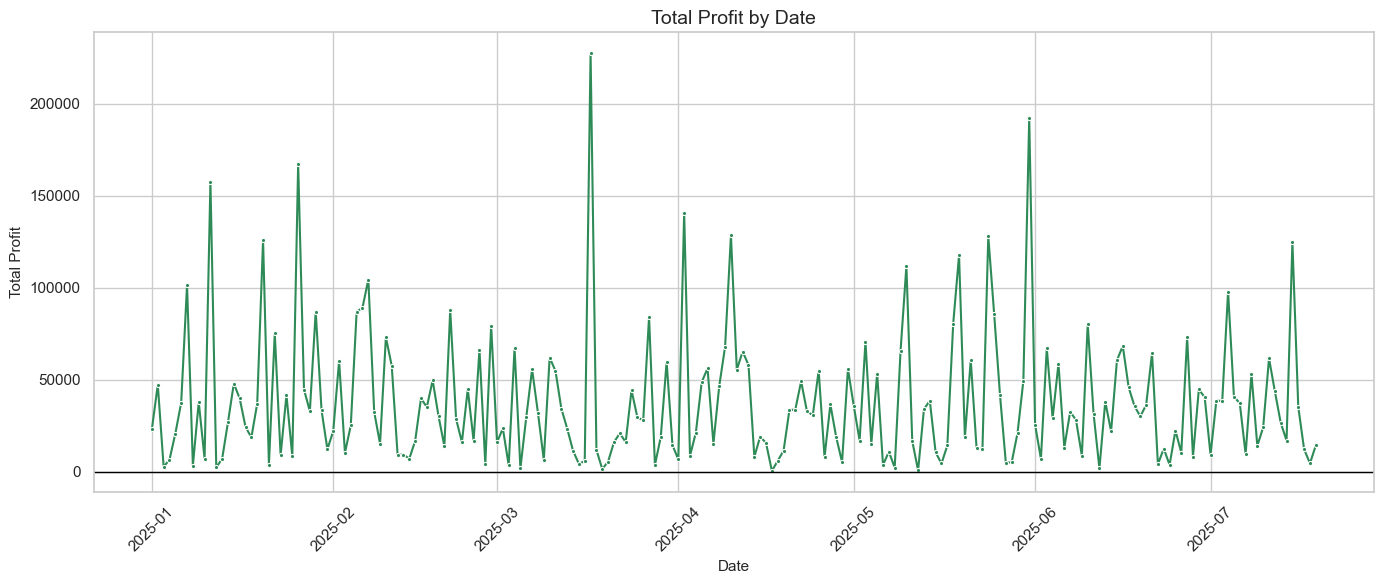

In [4]:
# Aggregate total profit by date
daily_profit = df.groupby("Order_Date", as_index=False)["Profit"].sum()

# Plot total profit by date
plt.figure(figsize=(14, 6))
sns.lineplot(data=daily_profit, x="Order_Date", y="Profit", marker="o", markersize=3, color="seagreen")
plt.axhline(0, color="black", linewidth=1)
plt.title("Total Profit by Date")
plt.xlabel("Date")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Highest-sales month: May 2025
Monthly sales: 4,972,117.25


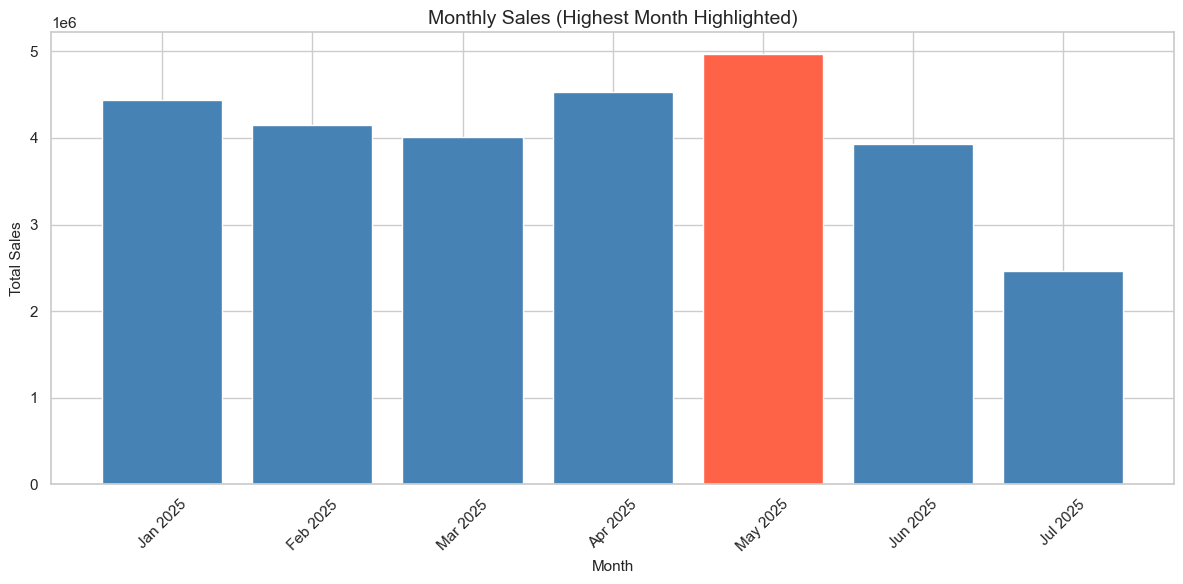

In [5]:
# Calculate monthly sales
monthly_sales = df.set_index("Order_Date").resample("MS")["Sales"].sum().reset_index()
highest_month = monthly_sales.loc[monthly_sales["Sales"].idxmax()]

# Print and highlight the highest-sales month
print(f"Highest-sales month: {highest_month['Order_Date']:%B %Y}")
print(f"Monthly sales: {highest_month['Sales']:,.2f}")
colors = ["tomato" if date == highest_month["Order_Date"] else "steelblue" for date in monthly_sales["Order_Date"]]
plt.figure(figsize=(12, 6))
plt.bar(monthly_sales["Order_Date"].dt.strftime("%b %Y"), monthly_sales["Sales"], color=colors)
plt.title("Monthly Sales (Highest Month Highlighted)")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

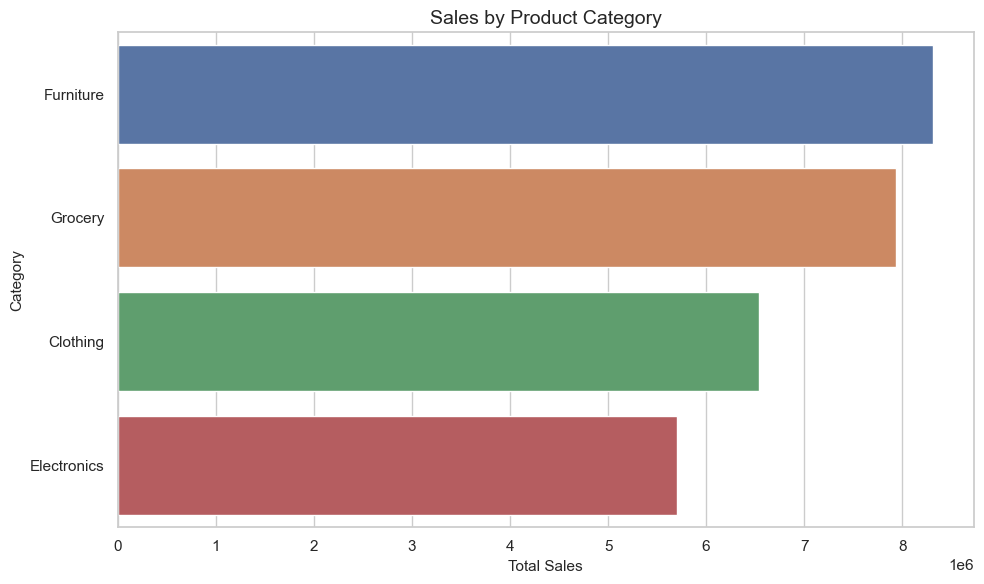

In [6]:
# Compare total sales across product categories
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=category_sales.values, y=category_sales.index, hue=category_sales.index, legend=False)
plt.title("Sales by Product Category")
plt.xlabel("Total Sales")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

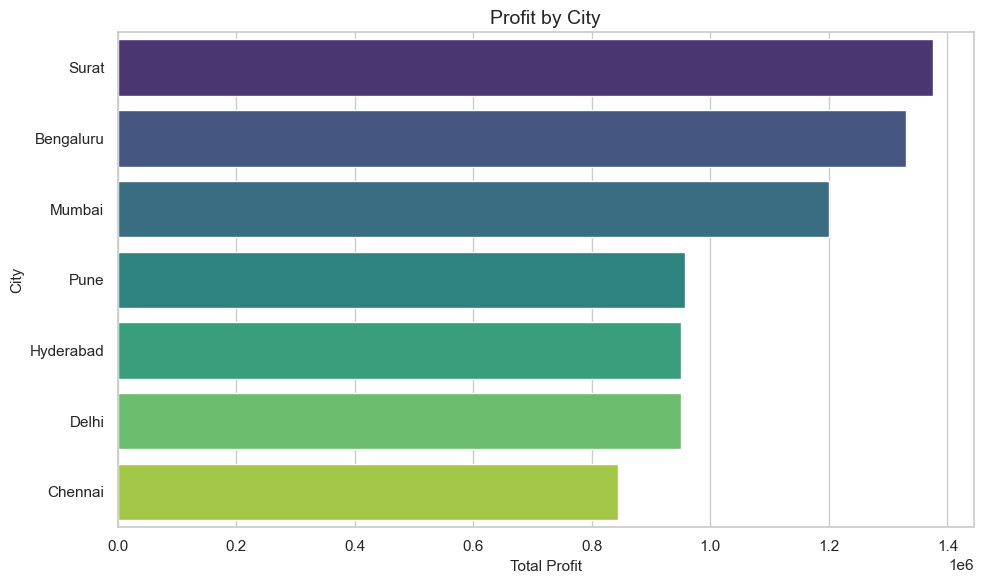

In [7]:
# Compare total profit across cities
city_profit = df.groupby("City")["Profit"].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=city_profit.values, y=city_profit.index, hue=city_profit.index, legend=False, palette="viridis")
plt.title("Profit by City")
plt.xlabel("Total Profit")
plt.ylabel("City")
plt.tight_layout()
plt.show()

Top 5 products by sales:
Product
Sofa      3127471.60
Snacks    2713070.85
Oil       2678849.65
Bed       2382264.00
Jacket    2368124.65


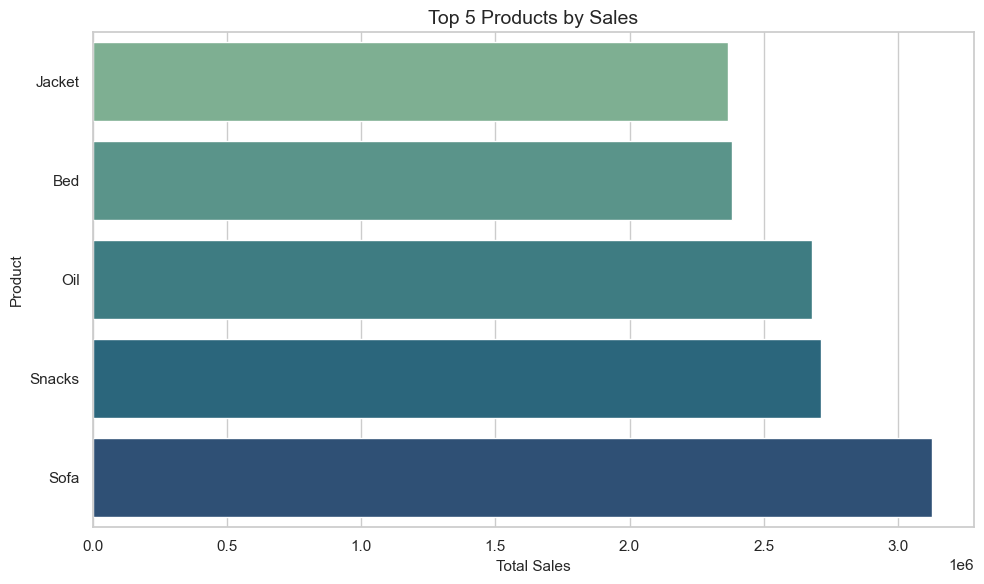

In [8]:
# Find the top five products by total sales
top_products = df.groupby("Product")["Sales"].sum().nlargest(5).sort_values()
print("Top 5 products by sales:")
print(top_products.sort_values(ascending=False).to_string())
plt.figure(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index, legend=False, palette="crest")
plt.title("Top 5 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

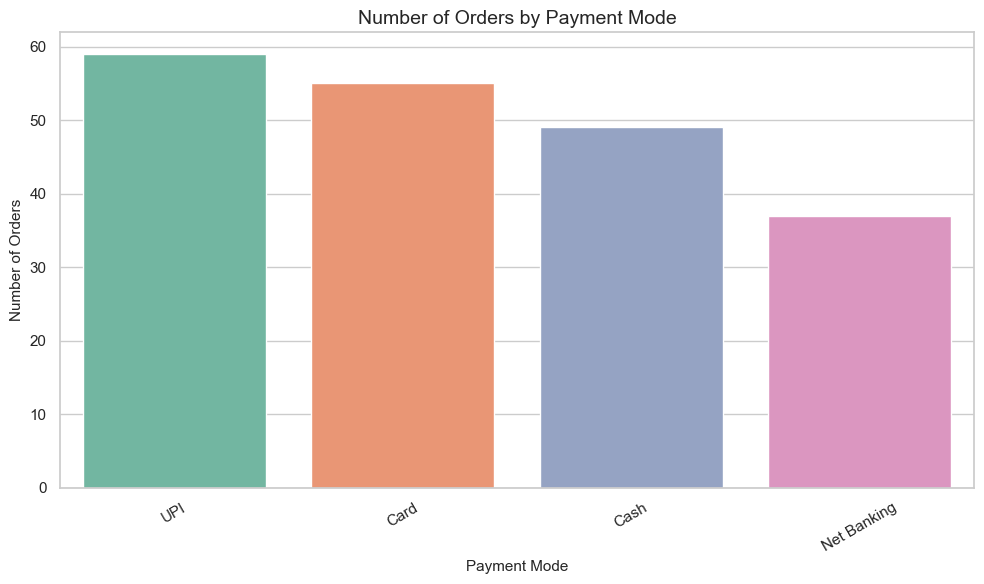

In [9]:
# Count unique orders for each payment mode
payment_orders = df.groupby("Payment_Mode")["Order_ID"].nunique().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=payment_orders.index, y=payment_orders.values, hue=payment_orders.index, legend=False, palette="Set2")
plt.title("Number of Orders by Payment Mode")
plt.xlabel("Payment Mode")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

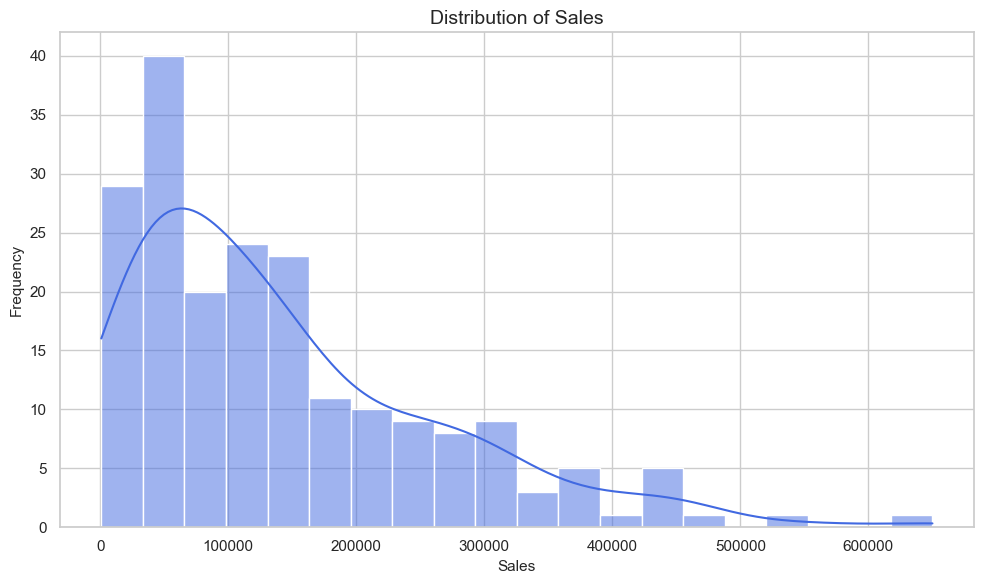

In [10]:
# Plot the distribution of sales
plt.figure(figsize=(10, 6))
sns.histplot(df["Sales"], bins=20, kde=True, color="royalblue")
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

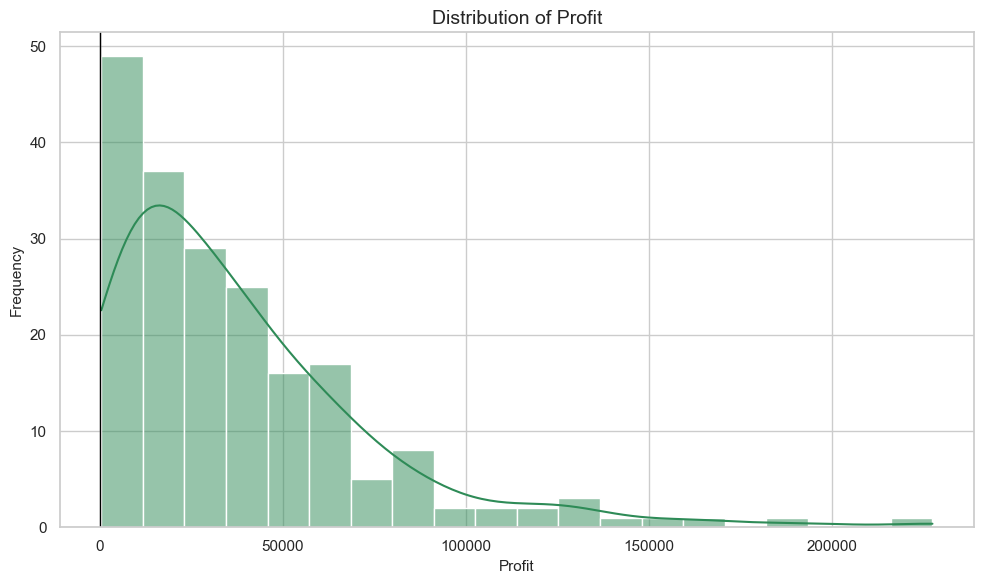

In [11]:
# Plot the distribution of profit
plt.figure(figsize=(10, 6))
sns.histplot(df["Profit"], bins=20, kde=True, color="seagreen")
plt.axvline(0, color="black", linewidth=1)
plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

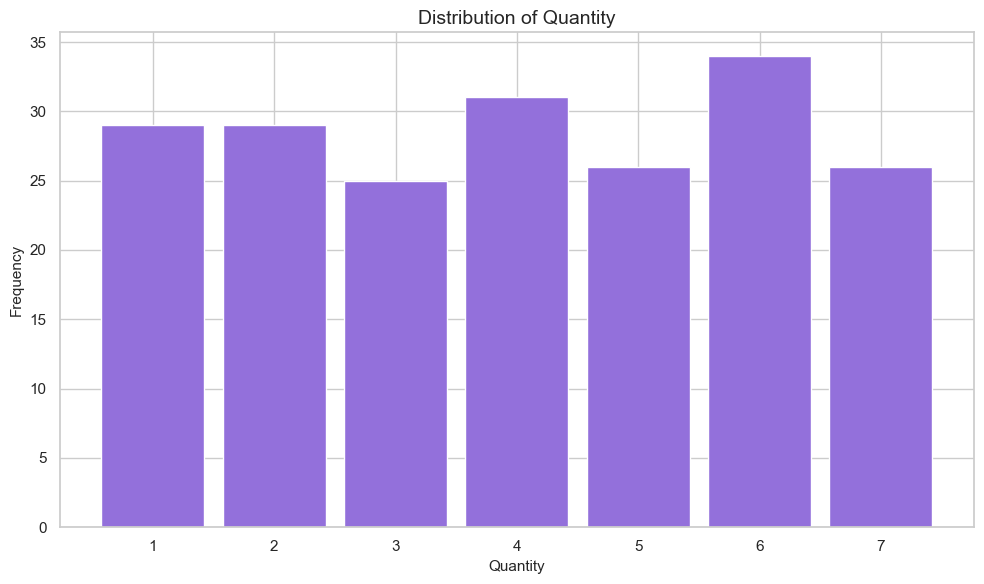

In [12]:
# Plot the distribution of quantity
quantity_bins = range(int(df["Quantity"].min()), int(df["Quantity"].max()) + 2)
plt.figure(figsize=(10, 6))
plt.hist(df["Quantity"], bins=quantity_bins, align="left", rwidth=0.85, color="mediumpurple", edgecolor="white")
plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.xticks(sorted(df["Quantity"].unique()))
plt.tight_layout()
plt.show()

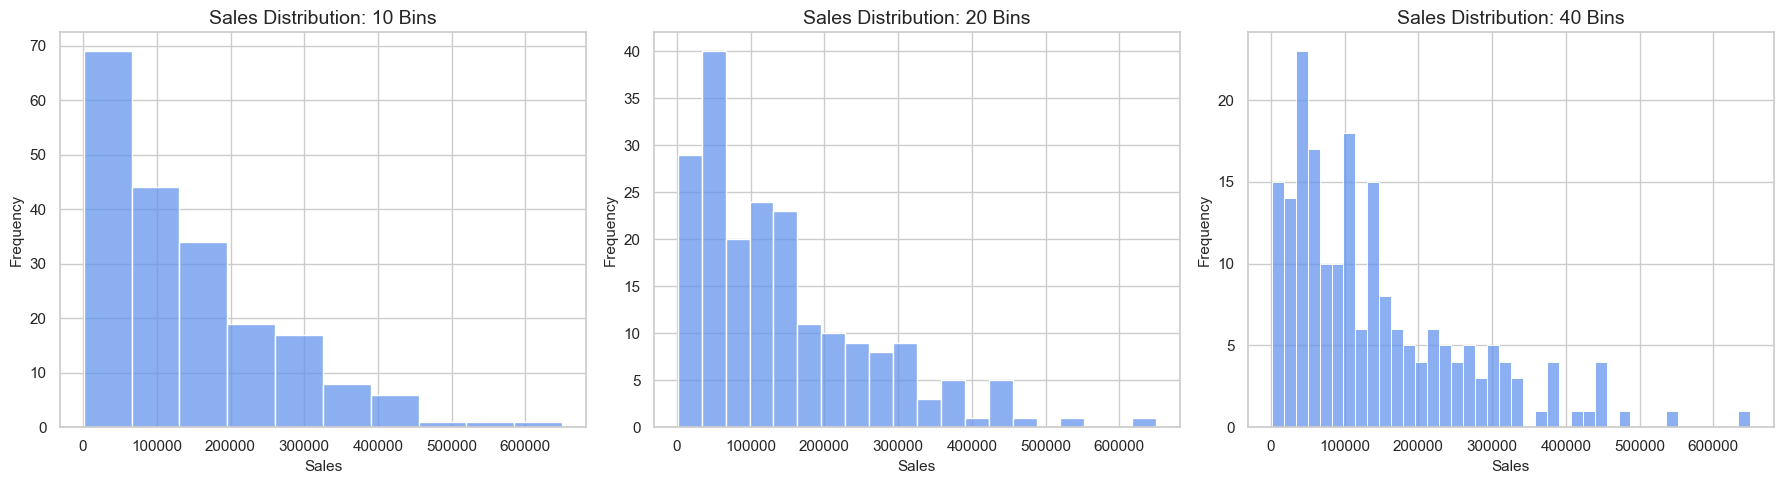

In [13]:
# Compare different bin counts for the Sales distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, bins in zip(axes, [10, 20, 40]):
    sns.histplot(df["Sales"], bins=bins, kde=False, ax=ax, color="cornflowerblue")
    ax.set_title(f"Sales Distribution: {bins} Bins")
    ax.set_xlabel("Sales")
    ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

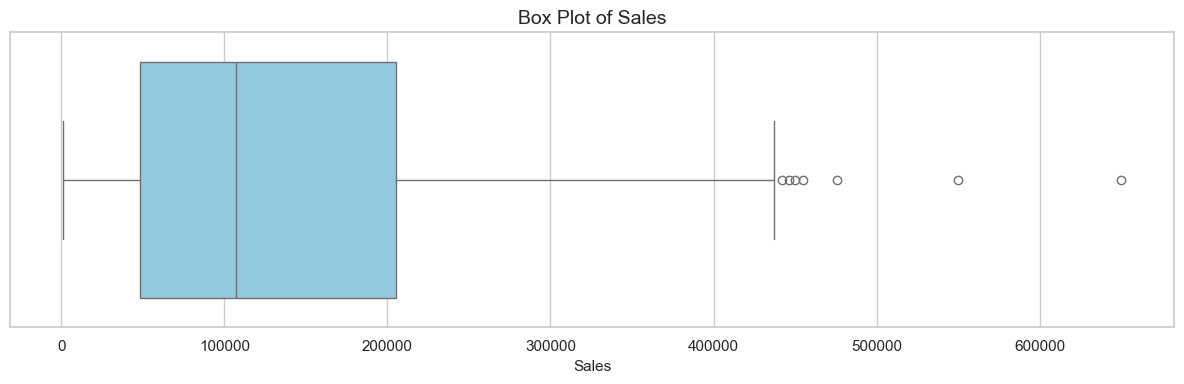

In [14]:
# Create a box plot for sales
plt.figure(figsize=(12, 4))
sns.boxplot(x=df["Sales"], color="skyblue")
plt.title("Box Plot of Sales")
plt.xlabel("Sales")
plt.tight_layout()
plt.show()

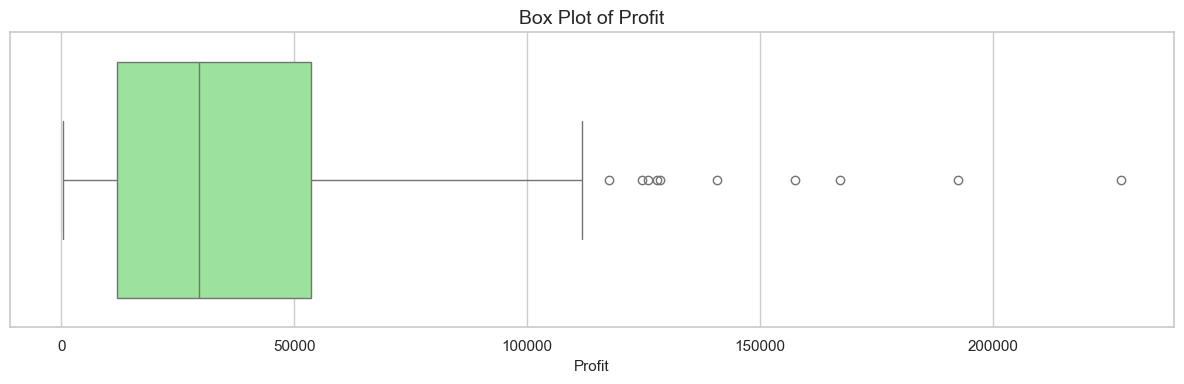

In [15]:
# Create a box plot for profit
plt.figure(figsize=(12, 4))
sns.boxplot(x=df["Profit"], color="lightgreen")
plt.title("Box Plot of Profit")
plt.xlabel("Profit")
plt.tight_layout()
plt.show()

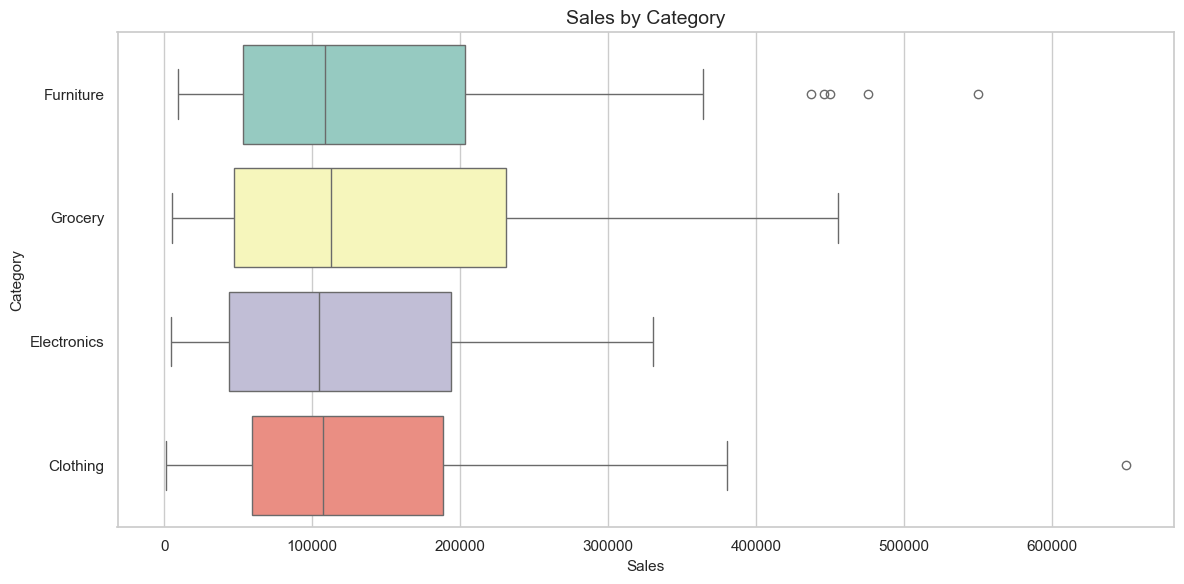

In [16]:
# Compare sales distributions across categories
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Sales", y="Category", hue="Category", legend=False, palette="Set3")
plt.title("Sales by Category")
plt.xlabel("Sales")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [17]:
# Identify possible outliers with the IQR rule
def iqr_outliers(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return lower_bound, upper_bound, outliers

sales_lower, sales_upper, sales_outliers = iqr_outliers(df, "Sales")
profit_lower, profit_upper, profit_outliers = iqr_outliers(df, "Profit")

# Display the outlier limits and possible outlier rows
print(f"Sales limits: {sales_lower:,.2f} to {sales_upper:,.2f}; possible outliers: {len(sales_outliers)}")
print(f"Profit limits: {profit_lower:,.2f} to {profit_upper:,.2f}; possible outliers: {len(profit_outliers)}")
possible_outliers = pd.concat([
    sales_outliers.assign(Outlier_Measure="Sales"),
    profit_outliers.assign(Outlier_Measure="Profit")
]).drop_duplicates(subset=["Order_ID", "Outlier_Measure"])
possible_outliers[["Order_ID", "Product", "Category", "Sales", "Profit", "Outlier_Measure"]].sort_values(["Outlier_Measure", "Order_ID"])

Sales limits: -187,321.12 to 440,943.07; possible outliers: 7
Profit limits: -50,365.26 to 116,017.72; possible outliers: 10


,Order_ID,Product,Category,Sales,Profit,Outlier_Measure
10,1011,Sofa,Furniture,450000.00,157500.00,Profit
19,1020,Sofa,Furniture,293972.75,125873.41,Profit
25,1026,Jeans,Clothing,380548.80,167188.31,Profit
75,1076,Jacket,Clothing,650000.00,227500.00,Profit
91,1092,Oil,Grocery,416717.00,140756.68,Profit
99,1100,Smart Watch,Electronics,306502.00,128499.79,Profit
138,1139,Bed,Furniture,446012.00,117680.21,Profit
143,1144,Tea,Grocery,383733.00,127980.51,Profit
150,1151,Bed,Furniture,550000.00,192500.00,Profit
195,1196,Jacket,Clothing,292748.20,124674.86,Profit


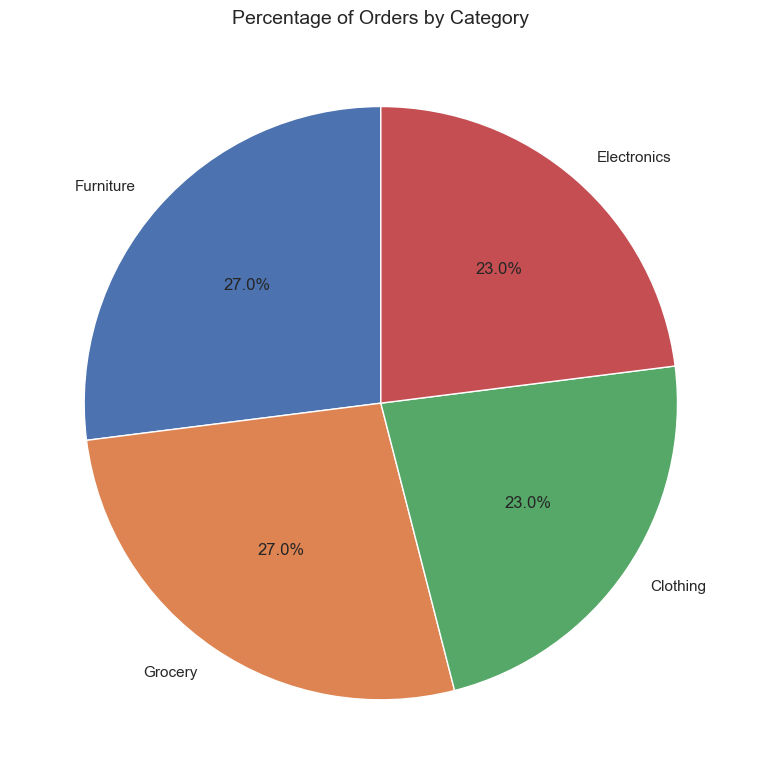

In [18]:
# Show the percentage of unique orders by category
category_orders = df.groupby("Category")["Order_ID"].nunique().sort_values(ascending=False)
plt.figure(figsize=(8, 8))
plt.pie(category_orders, labels=category_orders.index, autopct="%1.1f%%", startangle=90, wedgeprops={"edgecolor": "white"})
plt.title("Percentage of Orders by Category")
plt.tight_layout()
plt.show()

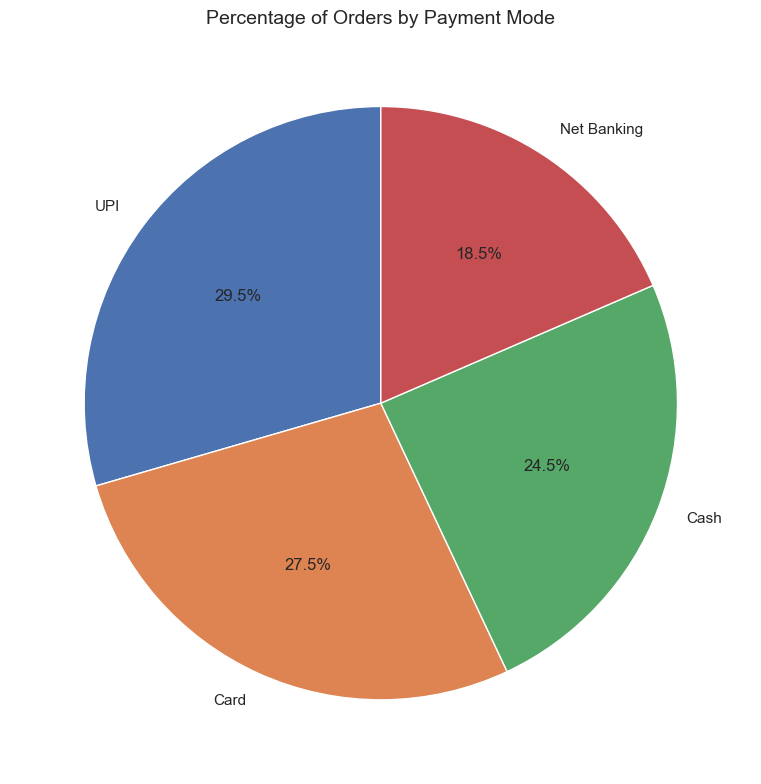

In [19]:
# Show the percentage of unique orders by payment mode
payment_mode_orders = df.groupby("Payment_Mode")["Order_ID"].nunique().sort_values(ascending=False)
plt.figure(figsize=(8, 8))
plt.pie(payment_mode_orders, labels=payment_mode_orders.index, autopct="%1.1f%%", startangle=90, wedgeprops={"edgecolor": "white"})
plt.title("Percentage of Orders by Payment Mode")
plt.tight_layout()
plt.show()

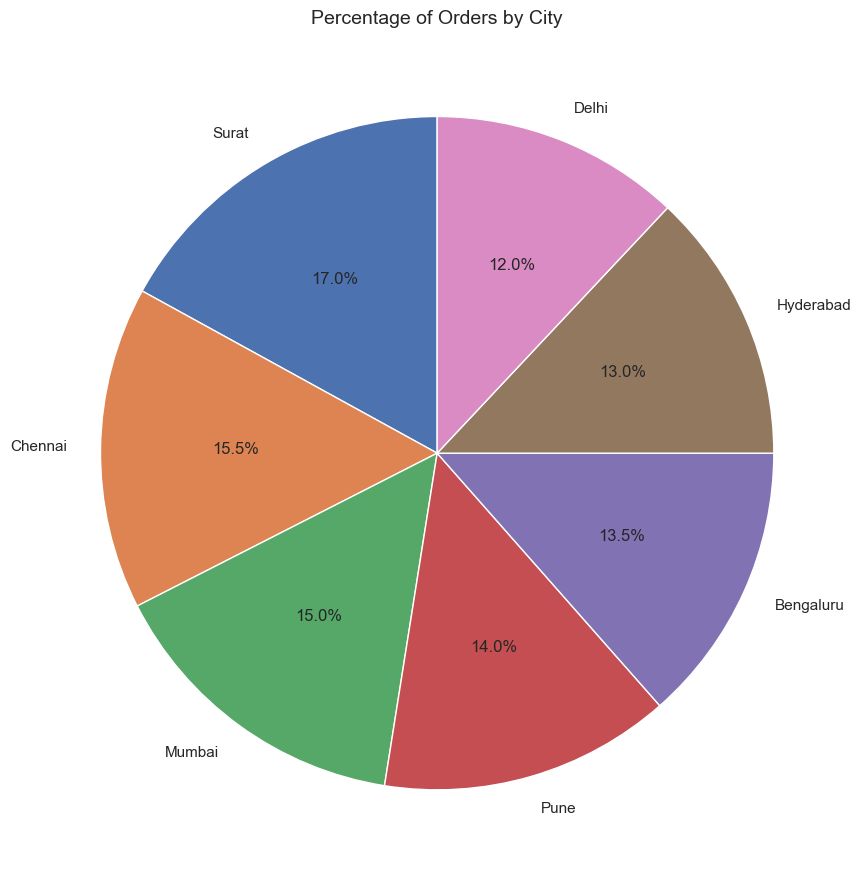

In [20]:
# Show the percentage of unique orders by city
city_orders = df.groupby("City")["Order_ID"].nunique().sort_values(ascending=False)
plt.figure(figsize=(9, 9))
plt.pie(city_orders, labels=city_orders.index, autopct="%1.1f%%", startangle=90, wedgeprops={"edgecolor": "white"})
plt.title("Percentage of Orders by City")
plt.tight_layout()
plt.show()